## Variational GPR on WeatherBench Data 
Apply GP regression baseline


In [ ]:
# Check GPU
!nvidia-smi

%load_ext autoreload
%autoreload 2

Sun Mar 16 16:55:42 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.12             Driver Version: 535.104.12   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          Off | 00000000:1B:00.0 Off |                    0 |
| N/A   39C    P0              39W / 250W |   4397MiB / 40960MiB |     23%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import time
from tqdm.notebook import tqdm

import torch
import gpytorch

from GPyTorch.GPRs.model import VarGP
from GPyTorch.GPRs.utils import latlon_to_cartesian, cartesian_to_latlon
from GPyTorch.GPRs.process_data import create_data

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

## Data Processing

Loading the data

In [5]:
z500 = xr.open_mfdataset('STGP-weather-forecasting/data/5.625deg/geopotential_500/*.nc', combine='by_coords')
z500_train_original = z500.sel(time=slice('2017.12', '2017.12', 6))['z']
z500_test_original = z500.sel(time=slice('2018.1', '2018.1', 6))['z'] # 2017-2018 data

In [6]:
## Normalize first then detrend (train on the residuals from normalised data)

# Normalize datasets
z500_train_mean = z500_train_original.mean().load()
z500_train_std = z500_train_original.std().load()
z500_train = (z500_train_original - z500_train_mean) / z500_train_std
z500_test = (z500_test_original - z500_train_mean) / z500_train_std

# Detrend to get residuals
data_train = xr.apply_ufunc(
    mstl_detrend,       
    z500_train.load(),                 
    input_core_dims=[['time']],  
    output_core_dims=[['time']],
    kwargs={'periods': periods},   
    vectorize=True,    
)

data_test = xr.apply_ufunc(
    mstl_detrend,       
    z500_test.load(),                 
    input_core_dims=[['time']],  
    output_core_dims=[['time']],
    kwargs={'periods': periods},   
    vectorize=True,    
)

# Data --> Normalised Data = Residual + Shift => Shift = Normalised - Residual
train_shift = z500_train - data_train
test_shift = z500_test - data_test

In [ ]:
## Detrend first then normalise (train on the normalised residuals)

# Detrend to get residuals
z500_train = xr.apply_ufunc(
    mstl_detrend,       
    z500_train_original.load(),                 
    input_core_dims=[['time']],  
    output_core_dims=[['time']],
    kwargs={'periods': periods},   
    vectorize=True,    
)

z500_test = xr.apply_ufunc(
    mstl_detrend,       
    z500_test_original.load(),                 
    input_core_dims=[['time']],  
    output_core_dims=[['time']],
    kwargs={'periods': periods},   
    vectorize=True,    
)

# Normalize datasets
data_mean = z500_train.mean().load()
data_std = z500_train.std().load()
data_train = (z500_train - data_mean) / data_std
data_test = (z500_test - data_mean) / data_std

# Data = Residual + Shift => Shift = Data - Residual
train_shift = z500_train_original - z500_train
test_shift = z500_test_original - z500_test

We need to convert (lat., lon.) coordinates into (x,y,z) for the inputs into the spatial kernel from GeometricKernel 

In [7]:
def latlon_to_cartesian(lat, lon, device=device):
    """ Converting (lat., lon.) to cartesian coordinates on a unit sphere
        Note: WeatherBench data is defined on a constant altitude """

    lat, lon = np.deg2rad(lat), np.deg2rad(lon)

    x = np.cos(lat)[:, None] * np.cos(lon)[None, :]
    y = np.cos(lat)[:, None] * np.sin(lon)[None, :]
    z = np.sin(lat)[:, None] * np.ones_like(lon)[None, :]

    xyz = np.stack([x, y, z], axis=-1)  # Out: (nlat, nlon, 3)
    return torch.tensor(xyz).to(device)

def cartesian_to_latlon(xyz):

    x = xyz[..., 0]
    y = xyz[..., 1]
    z = xyz[..., 2]

    lat = np.arcsin(z) 
    lon = np.arctan2(y, x)  
    lat_deg = np.degrees(lat)
    lon_deg = np.degrees(lon)
    lon_deg = (lon_deg + 360) % 360
    latlon = np.stack([lat_deg, lon_deg], axis=-1)
    return latlon

Subsampling the datasets due to memory issues

In [8]:
def create_data(data_train, data_test, lead_time_h, space_subsample=1, time_subsample=1, device=device, train=True):
    """Preparing input and output data. X should be the coordinate input into the kernel, 
    while Y should be the forecast target (shifted lead time)."""

    if lead_time_h == 0:
        X = data_train.isel(time=slice(0, None, time_subsample),
                        lat=slice(0, None, space_subsample),
                        lon=slice(0, None, space_subsample))
        
    else:
        X = data_train.isel(time=slice(0, -lead_time_h, time_subsample),
                            lat=slice(0, None, space_subsample),
                            lon=slice(0, None, space_subsample))
        Y = data_train.isel(time=slice(lead_time_h, None, time_subsample),
                    lat=slice(0, None, space_subsample),
                    lon=slice(0, None, space_subsample)) 

    # Preparing the input coords (should have shape (ntime, nlat, nlon, 4) if we have no subsampling)
    X_time = (X.time - data_train.time[0]).values / np.timedelta64(1, 'h')
    X_time = torch.tensor(X_time).to(device)
    t_steps = X_time.shape[0]

    latitudes = X.lat.values 
    longitudes = X.lon.values 
    cartesian_coords = latlon_to_cartesian(latitudes, longitudes, device)
    nlat, nlon, _ = cartesian_coords.shape

    if train:
        print("Processing Training Dataset")
        # Combine spatial and temporal data
        training_coords = torch.empty((t_steps, nlat, nlon, 4)).to(device)
        # Fill in the spatial part first
        training_coords[..., :3] = cartesian_coords.unsqueeze(0).expand(t_steps, -1, -1, -1)
        # The final element is time
        training_coords[..., 3] = X_time.view(t_steps, 1, 1).expand(t_steps, nlat, nlon)
        X_size = training_coords.element_size() * training_coords.nelement() / (1024**2)
        print(f"Combined coords info --> Shape: {training_coords.shape}, Mem: {X_size:.2f} MB")

        if lead_time_h == 0:
            Y = torch.tensor(X.values).view(-1).to(device)
        else:
            # Flatten to shape (N,)
            Y = torch.tensor(Y.values).view(-1).to(device)
            Y_size = Y.element_size() * Y.nelement() / (1024**2)
            print(f"Target info --> Shape: {Y.shape}, Mem: {Y_size:.2f} MB")

        return training_coords, Y
    
    else:
        # Testing Data
        if lead_time_h == 0:
            X_test = data_test.isel(time=slice(0, None, time_subsample),
                            lat=slice(0, None, space_subsample),
                            lon=slice(0, None, space_subsample))
        else:
            X_test = data_test.isel(time=slice(0, -lead_time_h, time_subsample),
                                lat=slice(0, None, space_subsample),
                                lon=slice(0, None, space_subsample))
            Y_test = data_test.isel(time=slice(lead_time_h, None, time_subsample),
                        lat=slice(0, None, space_subsample),
                        lon=slice(0, None, space_subsample))
        X_test_time = (X_test.time - data_train.time[0]).values / np.timedelta64(1, 'h')
        X_test_time = torch.tensor(X_test_time).to(device)
        test_t_steps = X_test_time.shape[0]

        print("Processing Test Dataset")
        # Combine spatial and temporal data
        testing_coords = torch.empty((test_t_steps, nlat, nlon, 4)).to(device)
        # Fill in the spatial part first
        testing_coords[..., :3] = cartesian_coords.unsqueeze(0).expand(test_t_steps, -1, -1, -1)
        # The final element is time
        testing_coords[..., 3] = X_test_time.view(test_t_steps, 1, 1).expand(test_t_steps, nlat, nlon)
        X_size = testing_coords.element_size() * testing_coords.nelement() / (1024**2)
        print(f"Combined coords info --> Shape: {testing_coords.shape}, Mem: {X_size:.2f} MB")

        if lead_time_h == 0:
            Y_test = torch.tensor(X_test.values).view(-1).to(device)
        else:
            # Flatten to shape (N,)
            Y_test = torch.tensor(Y_test.values).view(-1).to(device)
            Y_size = Y_test.element_size() * Y_test.nelement() / (1024**2)
            print(f"Target info --> Shape: {Y_test.shape}, Mem: {Y_size:.2f} MB")

        return testing_coords, Y_test, latitudes, longitudes

## Defining the Kernel

We work on the 2d-hypersphere, modeling the spatial kernel with Geometric_Kernel and time kernel with periodic kernel. 

In [9]:
spatial_length_1 = 0.04
spatial_length_2 = 0.08
spatial_length_3 = 0.5

# Define the GP regression kernel, separable in space and time
matern_spatial_1 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[0,1,2]).to(device)
matern_spatial_1.lengthscale = torch.tensor(spatial_length_1).to(device)
matern_spatial_1.register_prior("lengthscale_prior", gpytorch.priors.NormalPrior(spatial_length_1, spatial_length_1/5), "lengthscale")

matern_spatial_2 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[0,1,2]).to(device)
matern_spatial_2.lengthscale = torch.tensor(spatial_length_2).to(device)
matern_spatial_2.register_prior("lengthscale_prior", gpytorch.priors.NormalPrior(spatial_length_2, spatial_length_2/5), "lengthscale")

matern_spatial_3 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[0,1,2]).to(device)
matern_spatial_3.lengthscale = torch.tensor(spatial_length_3).to(device)
matern_spatial_3.register_prior("lengthscale_prior", gpytorch.priors.NormalPrior(spatial_length_3, spatial_length_3/5), "lengthscale")

# spatial_kernel = gpytorch.kernels.ScaleKernel(matern_spatial_1+matern_spatial_2+matern_spatial_3).to(device)
spatial_kernel = matern_spatial_1+matern_spatial_2+matern_spatial_3

In [10]:
# For temporal kernel
#time_kernel1 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) # Daily    
#time_kernel1.period_length = torch.tensor(24).to(device)
#time_kernel2 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) # Three days
#time_kernel2.period_length = torch.tensor(24*3).to(device)
#time_kernel3 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) # Weekly
#time_kernel3.period_length = torch.tensor(24*7).to(device)

#time_kernel1.register_prior("period_length_prior", gpytorch.priors.NormalPrior(24, 3), "period_length")
#time_kernel2.register_prior("period_length_prior", gpytorch.priors.NormalPrior(24*3, 9), "period_length")
#time_kernel3.register_prior("period_length_prior", gpytorch.priors.NormalPrior(24*7, 21), "period_length")
#time_kernel = time_kernel1 + time_kernel2 + time_kernel3

# Define the GP regression kernel, separable in space and time
#matern_time_1 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[3]).to(device)
#matern_time_1.lengthscale = torch.tensor(24).to(device)
matern_time_2 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[3]).to(device)
matern_time_2.lengthscale = torch.tensor(40).to(device)
time_kernel1 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) 
time_kernel1.period_length = torch.tensor(24).to(device)
time_kernel2 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) 
time_kernel2.period_length = torch.tensor(24*5).to(device)

time_kernel =  matern_time_2 + time_kernel1 + time_kernel2
# Construct the product kernel
# kernel = spatial_kernel * time_kernel
kernel = gpytorch.kernels.ScaleKernel(spatial_kernel * time_kernel).to(device)

# Approximate GP
class GPModel(ApproximateGP):
    def __init__(self, inducing_points):
        # inducing_points: tensor of shape (M, 4)
        variational_distribution = CholeskyVariationalDistribution(inducing_points.size(0))
        variational_strategy = VariationalStrategy(self, inducing_points, variational_distribution, learn_inducing_locations=True)
        super(GPModel, self).__init__(variational_strategy)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = kernel

    def forward(self, x):
        # x is expected to be of shape (N, 4) (flattened combined coords)
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

## Training and Evaluation

In [11]:
def train_gp(lead_time, data_train, data_test, space_subsample_ips, time_subsample_ips, space_subsample=1, time_subsample=1, frac=0.01, epochs=10, batch_size=2048, save_model=False, device=device):
    """
    Train a Gaussian Process model using GPyTorch. Can add subsampling the data for efficiency.
    """
    
    # Prepare training data (Here we do not subsample any of the training data)
    X_train, Y_train = create_data(data_train, data_test, lead_time, space_subsample, time_subsample)

    # Inducing points technique
    # Random sampling
    N = X_train.shape[0] * X_train.shape[1] * X_train.shape[2]
    n_inducing = int(frac * N) # Fraction of points to be chosen
    X_train = X_train.view(-1, 4)
    indices = torch.randperm(X_train.size(0))[:n_inducing]
    inducing_points = X_train[indices]

    # Regular sampling
    # inducing_points = X_train[::time_subsample_ips, ::space_subsample_ips, ::space_subsample_ips,:].reshape(-1, 4)
    # X_train = X_train.view(-1,4) # Shape: (ntime*nlat*nlon, 4)
    print(f"Number of inducing points / Total number of points: {inducing_points.size(0)/X_train.size(0)}")
    
    train_dataset = TensorDataset(X_train, Y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    #likelihood.noise = torch.tensor(1e-4).to(device)  
    #likelihood.noise_covar.raw_noise.requires_grad_(False)  
    model = GPModel(inducing_points).to(device)
    
    # Train model
    model.train()
    likelihood.train()

    # Optimizer
    optimizer = torch.optim.Adam([
        {'params': model.parameters()},
        {'params': likelihood.parameters()},
    ], lr=0.01)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.99)

    # Loss fn
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=len(train_dataset))

    print("Starting Variational GP regression training:")
    # Reset the peak memory statistics before training
    torch.cuda.reset_peak_memory_stats(device)
    hyperparams_track = []
    start_time = time.time()

    for epoch in range(epochs):
        epoch_loss = 0.0
        batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            output = model(x_batch)
            loss = -mll(output, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            batch_bar.set_postfix(loss=f"{loss.item():.3f}")
            batch_bar.update(1)

            #spatial_kernel = model.covar_module.kernels[0]
            #spatial1 = spatial_kernel.base_kernel.kernels[0]
            #spatial2 = spatial_kernel.base_kernel.kernels[1]
            #spatial3 = spatial_kernel.base_kernel.kernels[2]
            #time_sum_kernel = model.covar_module.kernels[1]
            #periodic1 = time_sum_kernel.kernels[0]
            #periodic2 = time_sum_kernel.kernels[1]
            #periodic3 = time_sum_kernel.kernels[2]

            #hyperparams_track.append({
            #    "loss": loss.item(),
            #    "mean": model.mean_module.constant.item(),
            #    "noise": likelihood.noise.item(),
            #    "spatial_1_lengthscale": spatial1.lengthscale.item(),
            #    "spatial_2_lengthscale": spatial2.lengthscale.item(),
            #    "spatial_3_lengthscale": spatial3.lengthscale.item(),
            #    "spatial_outputscale": spatial_kernel.outputscale.item(),
            #    "time_lengthscale_daily": periodic1.lengthscale.item(),
            #    "time_period_daily": periodic1.period_length.item(),
            #    "time_lengthscale_three_days": periodic2.lengthscale.item(),
            #    "time_period_three_days": periodic2.period_length.item(),
            #    "time_lengthscale_weekly": periodic3.lengthscale.item() ,
            #    "time_period_weekly": periodic3.period_length.item(),
            #})

            spatial_kernel = model.covar_module.base_kernel.kernels[0]
            temporal_kernel = model.covar_module.base_kernel.kernels[1]

            hyperparams_track.append({
                "loss": loss.item(),
                "mean": model.mean_module.constant.item(),
                "noise": likelihood.noise.item(),
                "outputscale": model.covar_module.outputscale.item(),
                "spatial_1_lengthscale": spatial_kernel.kernels[0].lengthscale.item(),
                "spatial_2_lengthscale": spatial_kernel.kernels[1].lengthscale.item(),
                "spatial_3_lengthscale": spatial_kernel.kernels[2].lengthscale.item(),
                #"matern_time_lengthscale_daily": temporal_kernel.kernels[0].lengthscale.item(),
                "matern_time_lengthscale_weekly": temporal_kernel.kernels[0].lengthscale.item(),
                "time_lengthscale_daily": temporal_kernel.kernels[1].lengthscale.item(),
                "time_period_daily": temporal_kernel.kernels[1].period_length.item(),
                "time_lengthscale_weekly": temporal_kernel.kernels[2].lengthscale.item(),
                "time_period_weekly": temporal_kernel.kernels[2].period_length.item(),
            })

        scheduler.step()
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss/len(train_loader):.3f}")
            
    current_allocated = torch.cuda.memory_allocated(device)
    max_allocated = torch.cuda.max_memory_allocated(device)
    print(f"Current GPU memory allocated: {current_allocated / (1024**2):.2f} MB")
    print(f"Peak GPU memory allocated: {max_allocated / (1024**2):.2f} MB")

    end_time = time.time()
    print("Training completed")
    time_elapsed = end_time - start_time
    print(f"Training time: {time_elapsed:.2f}s")

    # Save model
    if save_model:
        torch.save(model.state_dict(), "STGP-weather-forecasting/saved_models/vargp_model.pth")
        torch.save(likelihood.state_dict(), "STGP-weather-forecasting/saved_models/vargp_likelihood.pth")
        print("Saved model")

    return model, likelihood, hyperparams_track, X_train, Y_train, inducing_points

In [12]:
lead_time = 0 # units of hours
space_subsample_ips = 5 
time_subsample_ips = 6 
space_subsample = 1
time_subsample = 1
frac = 0.01
batch_size = 2048

# Train GP model
model, likelihood, hyperparams_track, X_train, Y_train, inducing_points = train_gp(lead_time, data_train, data_test, space_subsample_ips, time_subsample_ips, space_subsample, time_subsample, frac)

Processing Training Dataset
Combined coords info --> Shape: torch.Size([124, 32, 64, 4]), Mem: 7.75 MB
Number of inducing points / Total number of points: 0.009997952368951613
Starting Variational GP regression training:


Epoch 1/10:   0%|          | 0/124 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 2.344


Epoch 2/10:   0%|          | 0/124 [00:00<?, ?it/s]

Epoch 2/10 - Loss: 1.131


...

Epoch 8/10 - Loss: -0.532


Epoch 9/10:   0%|          | 0/124 [00:00<?, ?it/s]

Epoch 9/10 - Loss: -0.589


Epoch 10/10:   0%|          | 0/124 [00:00<?, ?it/s]

Epoch 10/10 - Loss: -0.616
Current GPU memory allocated: 406.49 MB
Peak GPU memory allocated: 3558.90 MB
Training completed
Training time: 158.68s


In [15]:
X_test, Y_test, lat, lon = create_data(data_train, data_test, lead_time, space_subsample=space_subsample, 
                                                time_subsample=time_subsample, device=device, train=False)
X_test = X_test.view(-1,4)
nlat = len(lat)
nlon = len(lon)

test_dataset = TensorDataset(X_test, Y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Make Predictions
model.eval()
likelihood.eval()
Y_pred = []
Y_std = []
with torch.no_grad():
    for x_batch, _ in test_loader:
        batch_pred = model(x_batch)
        Y_pred.append(batch_pred.mean)
        Y_std.append(batch_pred.stddev)
    Y_pred = torch.cat(Y_pred, dim=0)  
    Y_std = torch.cat(Y_std, dim=0) 

    mse = torch.mean((Y_pred - Y_test)**2)
    rmse = torch.sqrt(mse)
    print("MSE: ", mse.item())
    print("RMSE: ", rmse.item())

    # If detrend first then normalise
    #Y_pred_actual = (Y_pred.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon) + train_shift.values
    #Y_test_actual = (Y_test.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon) + test_shift.values

    # If normalise first then detrend
    Y_pred_actual = ((Y_pred.detach().cpu().numpy() + train_shift.values.reshape(-1)) * z500_train_std.values + z500_train_mean.values).reshape(-1,nlat,nlon) 
    Y_test_actual = ((Y_test.detach().cpu().numpy() + test_shift.values.reshape(-1)) * z500_train_std.values + z500_train_mean.values).reshape(-1,nlat,nlon) 

    err = Y_pred_actual - Y_test_actual
    weights_lat = np.cos(np.deg2rad(lat))
    weights_lat /= weights_lat.mean()
    wrmse = np.sqrt((err**2 * weights_lat[None, :, None]).mean())
    print("Weighted RMSE: ", wrmse)

Y_pred = Y_pred.detach().cpu().numpy()  
Y_test = Y_test.detach().cpu().numpy()  
Y_std = Y_std.detach().cpu().numpy()

Processing Test Dataset
Combined coords info --> Shape: torch.Size([124, 32, 64, 4]), Mem: 7.75 MB
MSE:  0.01203421883168055
RMSE:  0.10970058719843094
Weighted RMSE:  1032.1789637934203


## Performance Plots 

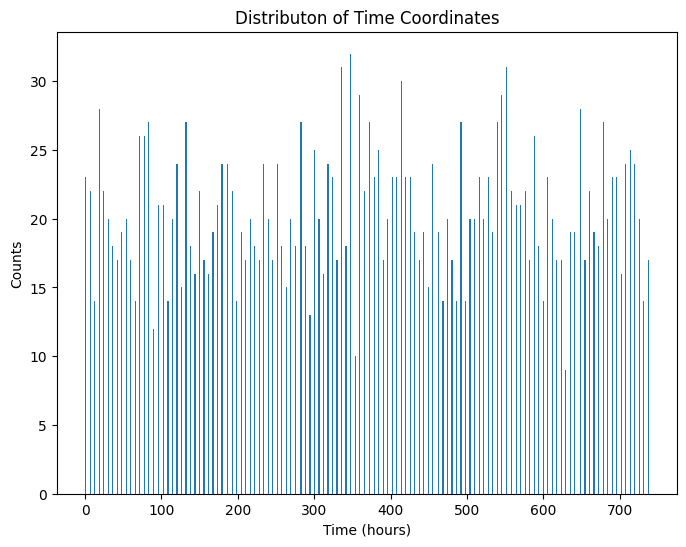

In [16]:
rand_coords = inducing_points[:,:3].detach().cpu().numpy()
rand_time = inducing_points[:,3].detach().cpu().numpy()

plt.figure(figsize=(8,6))
plt.hist(rand_time, bins=500)
plt.xlabel('Time (hours)')
plt.ylabel('Counts')
plt.title('Distributon of Time Coordinates')
plt.savefig("STGP-weather-forecasting/tmp/rand time dist.png")
plt.show()

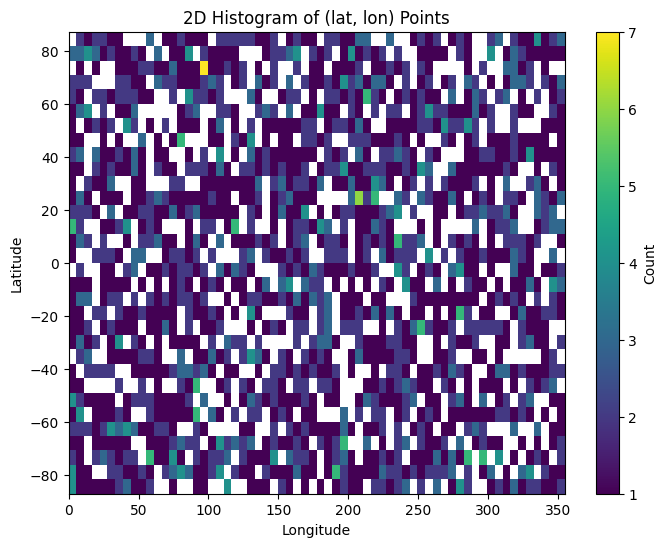

In [17]:
latlon = cartesian_to_latlon(rand_coords)
lat = latlon[:, 0]
lon = latlon[:, 1]

cmap = plt.get_cmap('viridis').copy()
cmap.set_under('white')

plt.figure(figsize=(8,6))
plt.hist2d(lon, lat, bins=[64, 32], cmap=cmap, vmin=1) # highlights bin with 0 counts as red
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('2D Histogram of (lat, lon) Points')
plt.colorbar(label='Count')
plt.savefig("STGP-weather-forecasting/tmp/rand space dist.png")
plt.show()

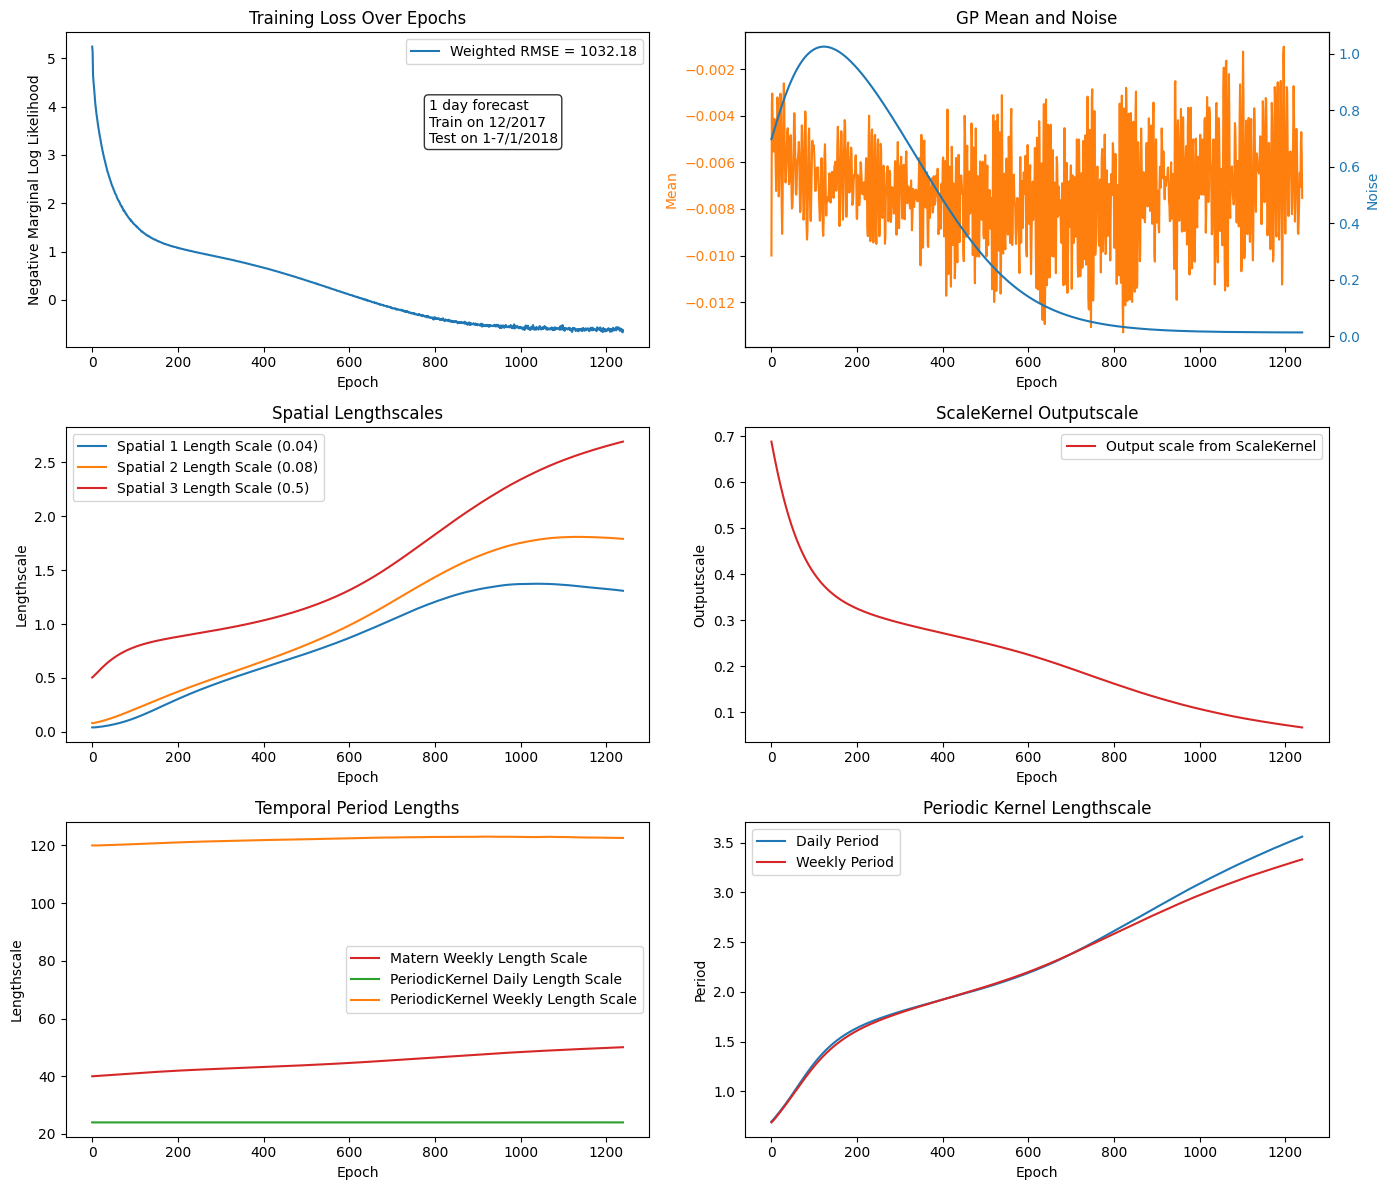

In [18]:
# Convert your tracking list into a DataFrame
df = pd.DataFrame(hyperparams_track)
epochs_range = np.arange(len(df))

# Create a figure with 3 rows and 2 columns of subplots
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))

# --- Row 1 ---
# Left: Loss
axs[0, 0].plot(epochs_range, df["loss"], label=f'Weighted RMSE = {wrmse:.2f}', color='tab:blue')
axs[0, 0].set_title("Training Loss Over Epochs")
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].set_ylabel("Negative Marginal Log Likelihood")
axs[0, 0].legend()

axs[0, 0].text(
    0.6215, 0.65, 
    f"1 day forecast\nTrain on 12/2017\nTest on 1-7/1/2018",
    transform=axs[0, 0].transAxes,  # interpret (x, y) as axes-relative
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, boxstyle='round')
)

# Right: Mean and Noise
axs[0, 1].plot(epochs_range, df["mean"], color='tab:orange', label="Mean")
axs[0, 1].set_title("GP Mean and Noise")
axs[0, 1].set_xlabel("Epoch")
axs[0, 1].set_ylabel("Mean", color='tab:orange')
axs[0, 1].tick_params(axis='y', labelcolor='tab:orange')
ax_noise = axs[0, 1].twinx()
ax_noise.plot(epochs_range, df["noise"], color='tab:blue', label="Noise")
ax_noise.set_ylabel("Noise", color='tab:blue')
ax_noise.tick_params(axis='y', labelcolor='tab:blue')

# --- Row 2 ---
# Left: Spatial lengthscales 
axs[1, 0].plot(epochs_range, df["spatial_1_lengthscale"], label=f'Spatial 1 Length Scale ({spatial_length_1})', color='tab:blue')
axs[1, 0].plot(epochs_range, df["spatial_2_lengthscale"], label=f'Spatial 2 Length Scale ({spatial_length_2})', color='tab:orange')
axs[1, 0].plot(epochs_range, df["spatial_3_lengthscale"], label=f'Spatial 3 Length Scale ({spatial_length_3})' , color='tab:red')
axs[1, 0].set_title("Spatial Lengthscales")
axs[1, 0].set_xlabel("Epoch")
axs[1, 0].set_ylabel("Lengthscale")
axs[1, 0].legend()

# Right: Spatial outputscale
#axs[1, 1].plot(epochs_range, df["spatial_outputscale"], label='Output scale from ScaleKernel', color='tab:red')
axs[1, 1].plot(epochs_range, df["outputscale"], label='Output scale from ScaleKernel', color='tab:red')
axs[1, 1].set_title("ScaleKernel Outputscale")
axs[1, 1].set_xlabel("Epoch")
axs[1, 1].set_ylabel("Outputscale")
axs[1, 1].legend()

# --- Row 3 ---
# Left: Temporal lengthscales
#axs[2, 0].plot(epochs_range, df["matern_time_lengthscale_daily"], label='Matern Daily Length Scale', color='tab:blue')
axs[2, 0].plot(epochs_range, df["matern_time_lengthscale_weekly"], label='Matern Weekly Length Scale', color='tab:red')
axs[2, 0].plot(epochs_range, df["time_period_daily"], label='PeriodicKernel Daily Length Scale', color='tab:green')
axs[2, 0].plot(epochs_range, df["time_period_weekly"], label='PeriodicKernel Weekly Length Scale', color='tab:orange')
axs[2, 0].set_title("Temporal Period Lengths")
axs[2, 0].set_xlabel("Epoch")
axs[2, 0].set_ylabel("Lengthscale")
axs[2, 0].legend()

# Right: Temporal periods
axs[2, 1].plot(epochs_range, df["time_lengthscale_daily"], label='Daily Period', color='tab:blue')
# axs[2, 1].plot(epochs_range, df["time_period_three_days"], label='3-Day Period', color='tab:orange')
axs[2, 1].plot(epochs_range, df["time_lengthscale_weekly"], label='Weekly Period', color='tab:red')
axs[2, 1].set_title("Periodic Kernel Lengthscale")
axs[2, 1].set_xlabel("Epoch")
axs[2, 1].set_ylabel("Period")
axs[2, 1].legend()

plt.tight_layout()
plt.savefig("STGP-weather-forecasting/tmp/output.png")
plt.show()

Note that the `lat` array is aranged from (-90 to 90) and `lon` from (0 to 360). So lat index 0 actually corresponds to points closer to the -90 degree mark --> Southpole (also towards lat=90 is the northpole while towards lat=-90 is the southpole).

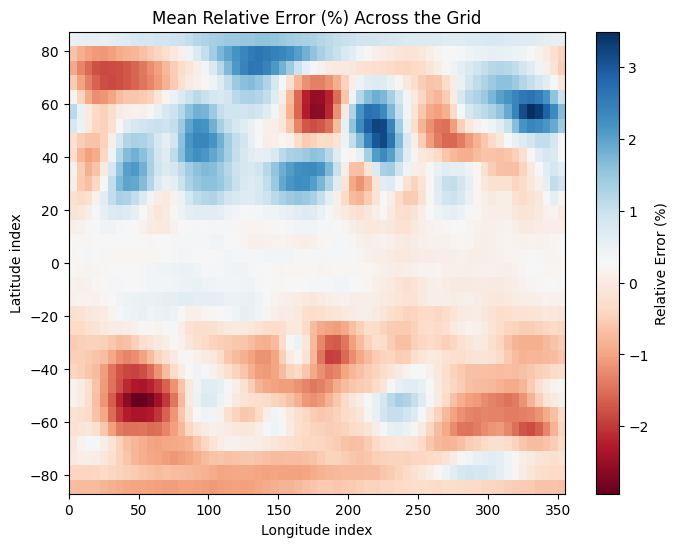

In [19]:
relative_error = (Y_pred_actual - Y_test_actual) / Y_test_actual * 100  
relative_error_mean = relative_error.mean(axis=0)  

plt.figure(figsize=(8, 6))
im = plt.imshow(relative_error_mean, cmap='RdBu', aspect='auto',
                extent=[lon.min(), lon.max(), lat.min(), lat.max()],
                origin='lower')
plt.title('Mean Relative Error (%) Across the Grid')
plt.xlabel('Longitude index')
plt.ylabel('Latitude index')
plt.colorbar(im, label='Relative Error (%)')
plt.savefig("STGP-weather-forecasting/tmp/relative err grid.png")
plt.show()

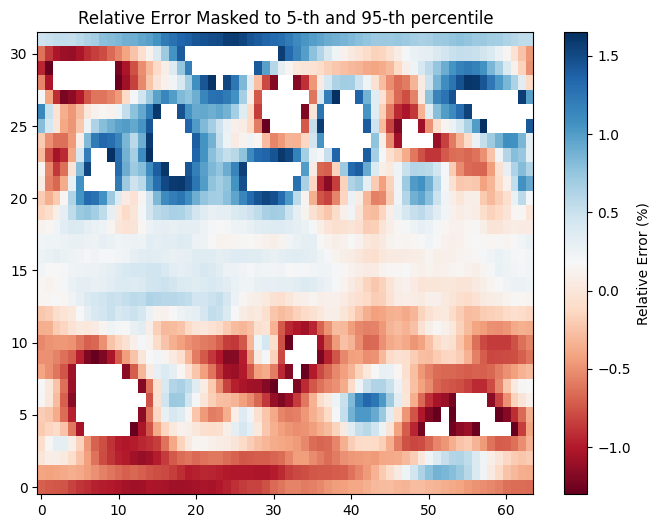

In [20]:
low_q = np.percentile(relative_error_mean, 5)
high_q = np.percentile(relative_error_mean, 95)
masked_error = np.ma.masked_outside(relative_error_mean, low_q, high_q)

plt.figure(figsize=(8, 6))
im = plt.imshow(masked_error, cmap='RdBu', aspect='auto', origin='lower')
plt.colorbar(im, label='Relative Error (%)')
plt.title('Relative Error Masked to 5-th and 95-th percentile')
plt.savefig("STGP-weather-forecasting/tmp/masked relative err grid.png")
plt.show()

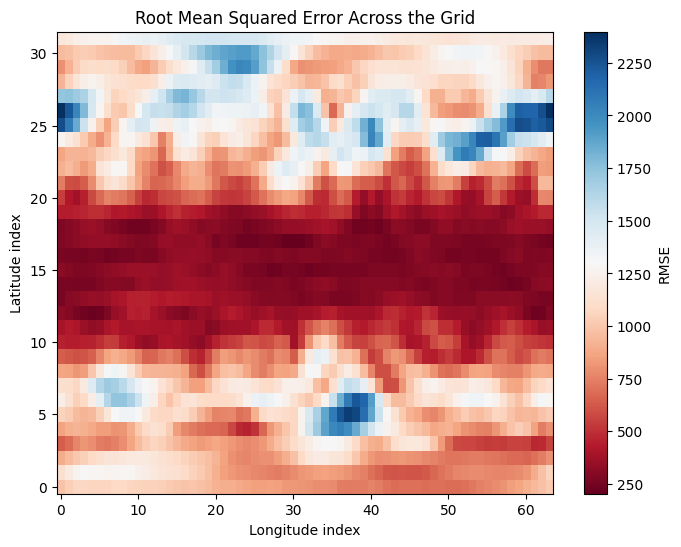

In [21]:
rmse_error = np.sqrt((Y_pred_actual - Y_test_actual)**2)
rmse_error_mean = rmse_error.mean(axis=0)  # shape (7, 13)

plt.figure(figsize=(8, 6))
im = plt.imshow(rmse_error_mean, cmap='RdBu', aspect='auto', origin='lower')
plt.title('Root Mean Squared Error Across the Grid')
plt.xlabel('Longitude index')
plt.ylabel('Latitude index')
plt.colorbar(im, label='RMSE')
plt.savefig("STGP-weather-forecasting/tmp/rmse err grid.png")
plt.show()

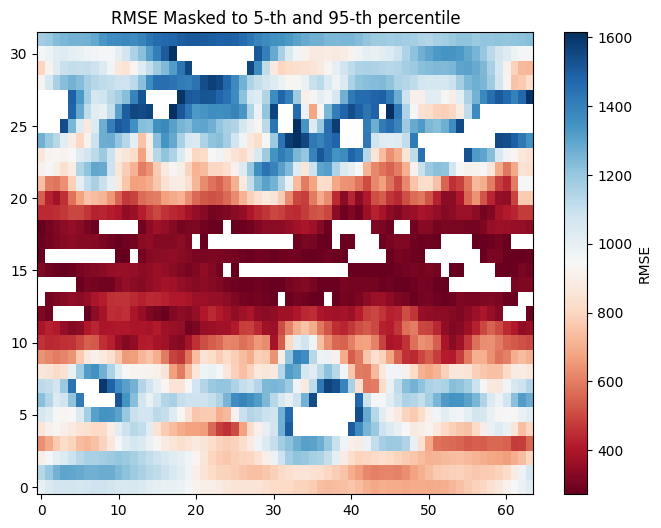

In [22]:
low_q_rmse = np.percentile(rmse_error_mean, 5)
high_q_rmse = np.percentile(rmse_error_mean, 95)
masked_error_rmse = np.ma.masked_outside(rmse_error_mean, low_q_rmse, high_q_rmse)

plt.figure(figsize=(8, 6))
im = plt.imshow(masked_error_rmse, cmap='RdBu', aspect='auto', origin='lower')
plt.colorbar(im, label='RMSE')
plt.title('RMSE Masked to 5-th and 95-th percentile')
plt.savefig("STGP-weather-forecasting/tmp/masked rmse err grid.png")
plt.show()

In [23]:
# Best and worst location based on relative error 
max_idx = np.argmax(relative_error_mean)
min_idx = np.argmin(relative_error_mean)
best_idx = np.argmin(np.abs(relative_error_mean))

flat_max_idx = np.unravel_index(max_idx, relative_error_mean.shape)
flat_min_idx = np.unravel_index(min_idx, relative_error_mean.shape)
flat_best_idx = np.unravel_index(best_idx, relative_error_mean.shape)

max_err = relative_error_mean[flat_max_idx[0],flat_max_idx[1]]
min_err = relative_error_mean[flat_min_idx[0],flat_min_idx[1]]
best_err = relative_error_mean[flat_best_idx[0],flat_best_idx[1]]

print(f"Highest relative error: ({int(flat_max_idx[0])},{int(flat_max_idx[1])}), with relative error in percentage: {max_err:.3f}")
print(f"Lowest relative error: ({int(flat_min_idx[0])},{int(flat_min_idx[1])}), with relative error in percentage: {min_err:.3f}")
print(f"Smallest relative error: ({int(flat_best_idx[0])},{int(flat_best_idx[1])}), with relative error in percentage: {best_err:.3f}")

Highest relative error: (26,59), with relative error in percentage: 3.491
Lowest relative error: (6,9), with relative error in percentage: -2.937
Smallest relative error: (25,2), with relative error in percentage: -0.001


In [24]:
# Best and worst location based on rmse
rmse_max_idx = np.argmax(rmse_error_mean)
rmse_min_idx = np.argmin(rmse_error_mean)

flat_rmse_max_idx = np.unravel_index(rmse_max_idx, rmse_error_mean.shape)
flat_rmse_min_idx = np.unravel_index(rmse_min_idx, rmse_error_mean.shape)

rmse_max_err = rmse_error_mean[flat_rmse_max_idx[0],flat_rmse_max_idx[1]]
rmse_min_err = rmse_error_mean[flat_rmse_min_idx[0],flat_rmse_min_idx[1]]

print(f"Highest RMSE: ({int(flat_rmse_max_idx[0])},{int(flat_rmse_max_idx[1])}), with value: {rmse_max_err:.3f}")
print(f"Lowest RMSE: ({int(flat_rmse_min_idx[0])},{int(flat_rmse_min_idx[1])}), with value: {rmse_min_err:.3f}")

Highest RMSE: (26,63), with value: 2397.381
Lowest RMSE: (17,30), with value: 204.012


In [23]:
"""results = []
spatial_kernel = model.covar_module.kernels[0]
spatial1 = spatial_kernel.base_kernel.kernels[0]
spatial2 = spatial_kernel.base_kernel.kernels[1]
spatial3 = spatial_kernel.base_kernel.kernels[2]
time_sum_kernel = model.covar_module.kernels[1]
periodic1 = time_sum_kernel.kernels[0]
periodic2 = time_sum_kernel.kernels[1]
periodic3 = time_sum_kernel.kernels[2]

results.append({
    "mean": model.mean_module.constant.item(),
    "noise": likelihood.noise.item(),
    "spatial_1_lengthscale": spatial1.lengthscale.item(),
    "spatial_2_lengthscale": spatial2.lengthscale.item(),
    "spatial_3_lengthscale": spatial3.lengthscale.item(),
    "spatial_outputscale": spatial_kernel.outputscale.item(),
    "time_lengthscale_daily": periodic1.lengthscale.item(),
    "time_period_daily": periodic1.period_length.item(),
    "time_lengthscale_three_days": periodic2.lengthscale.item(),
    "time_period_three_days": periodic2.period_length.item(),
    "time_lengthscale_weekly": periodic3.lengthscale.item() ,
    "time_period_weekly": periodic3.period_length.item(),
})
results"""

'results = []\nspatial_kernel = model.covar_module.kernels[0]\nspatial1 = spatial_kernel.base_kernel.kernels[0]\nspatial2 = spatial_kernel.base_kernel.kernels[1]\nspatial3 = spatial_kernel.base_kernel.kernels[2]\ntime_sum_kernel = model.covar_module.kernels[1]\nperiodic1 = time_sum_kernel.kernels[0]\nperiodic2 = time_sum_kernel.kernels[1]\nperiodic3 = time_sum_kernel.kernels[2]\n\nresults.append({\n    "mean": model.mean_module.constant.item(),\n    "noise": likelihood.noise.item(),\n    "spatial_1_lengthscale": spatial1.lengthscale.item(),\n    "spatial_2_lengthscale": spatial2.lengthscale.item(),\n    "spatial_3_lengthscale": spatial3.lengthscale.item(),\n    "spatial_outputscale": spatial_kernel.outputscale.item(),\n    "time_lengthscale_daily": periodic1.lengthscale.item(),\n    "time_period_daily": periodic1.period_length.item(),\n    "time_lengthscale_three_days": periodic2.lengthscale.item(),\n    "time_period_three_days": periodic2.period_length.item(),\n    "time_lengthscale_w

## Observing how the individual point performs

In [25]:
train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

model.eval()
likelihood.eval()
train_mean = []
train_std = []
Y_train = []
with torch.no_grad():
    for x_batch, y_batch in train_loader:
        pred_train = model(x_batch)
        train_mean.append(pred_train.mean)
        train_std.append(pred_train.stddev)
        Y_train.append(y_batch)
    train_mean = torch.cat(train_mean, dim=0)  
    train_std = torch.cat(train_std, dim=0) 
    Y_train = torch.cat(Y_train, dim=0) 
    
train_mean = train_mean.detach().cpu().numpy()  
train_std = train_std.detach().cpu().numpy()  
Y_train = Y_train.detach().cpu().numpy()

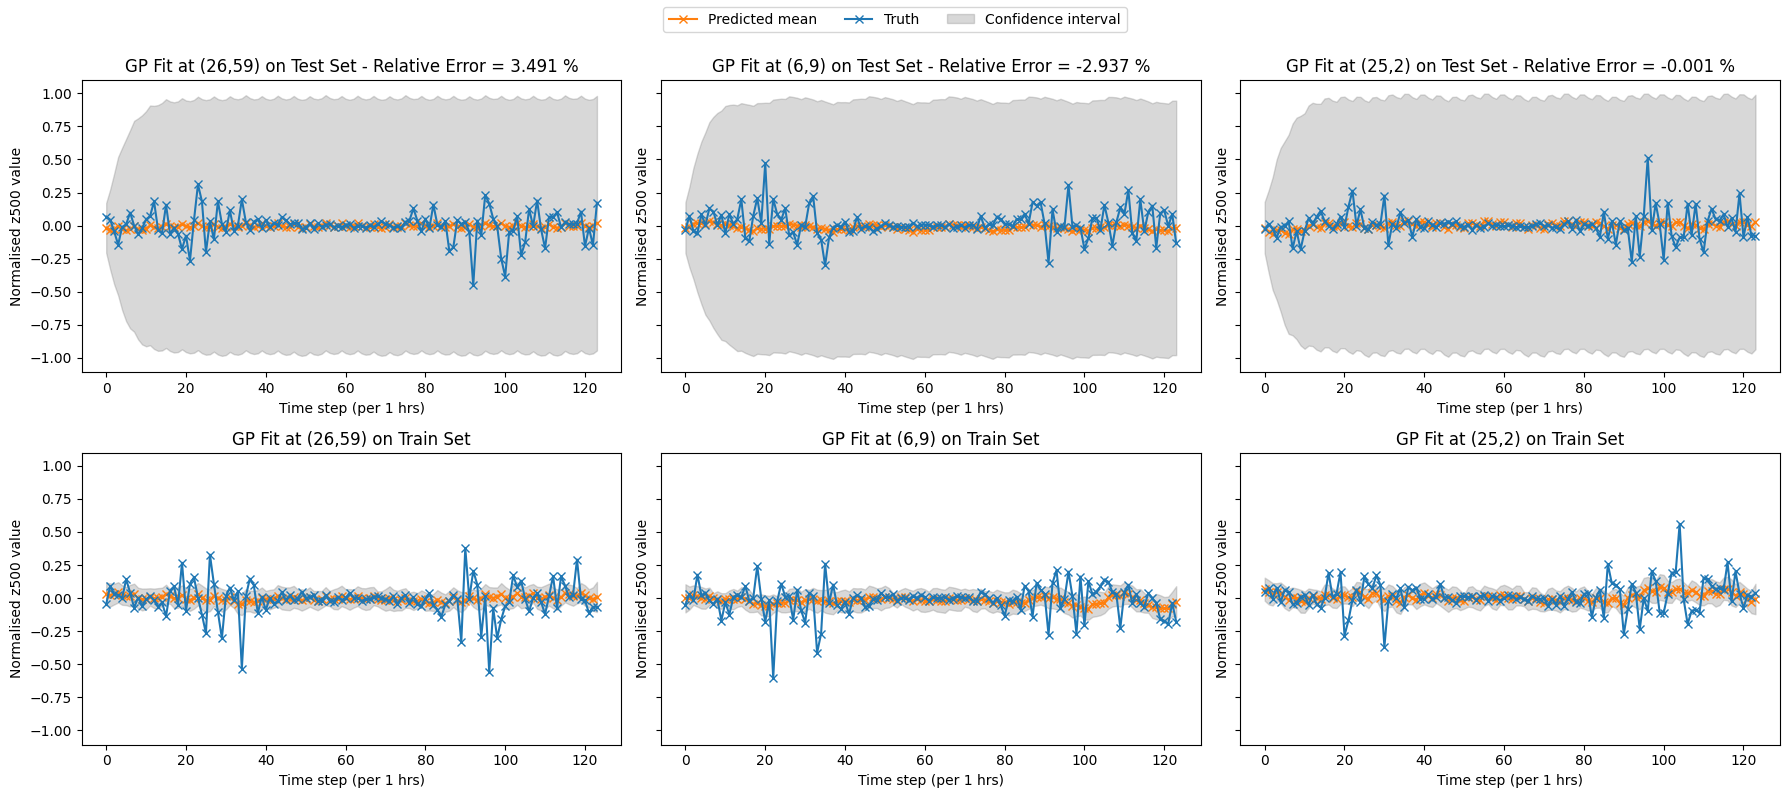

In [26]:
# Create a 2x3 figure
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=True)

idx = [max_idx, min_idx, best_idx]
val = [max_err, min_err, best_err]

for i, p_idx in enumerate(idx):
    flat_idx = np.unravel_index(p_idx, relative_error_mean.shape)
    ax = axes[0, i]  

    pred_vals = Y_pred.reshape(-1)[p_idx::(nlat*nlon)]
    truth_vals = Y_test.reshape(-1)[p_idx::(nlat*nlon)]
    std_vals = Y_std.reshape(-1)[p_idx::(nlat*nlon)]

    ax.plot(pred_vals, marker='x', label='Predicted mean', color='tab:orange')
    ax.plot(truth_vals, marker='x', label='Truth', color='tab:blue')
    ax.fill_between(np.arange(len(pred_vals)),
                    pred_vals - 2 * std_vals,
                    pred_vals + 2 * std_vals,
                    alpha=0.3, color='tab:gray', label='Confidence interval')
    ax.set_xlabel(f"Time step (per {time_subsample} hrs)")
    ax.set_ylabel("Normalised z500 value")
    ax.set_title(f"GP Fit at ({int(flat_idx[0])},{int(flat_idx[1])}) on Test Set - Relative Error = {val[i]:.3f} %")

for i, p_idx in enumerate(idx):
    flat_idx = np.unravel_index(p_idx, relative_error_mean.shape)
    ax = axes[1, i]  

    pred_vals = train_mean.reshape(-1)[p_idx::(nlat*nlon)]
    truth_vals = Y_train.reshape(-1)[p_idx::(nlat*nlon)]
    std_vals = train_std.reshape(-1)[p_idx::(nlat*nlon)]

    ax.plot(pred_vals, marker='x', label='Predicted mean', color='tab:orange')
    ax.plot(truth_vals, marker='x', label='Truth', color='tab:blue')
    ax.fill_between(np.arange(len(pred_vals)),
                    pred_vals - 2 * std_vals,
                    pred_vals + 2 * std_vals,
                    alpha=0.3, color='tab:gray', label='Confidence interval')
    ax.set_xlabel(f"Time step (per {time_subsample} hrs)")
    ax.set_ylabel("Normalised z500 value")
    ax.set_title(f"GP Fit at ({int(flat_idx[0])},{int(flat_idx[1])}) on Train Set")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.savefig("STGP-weather-forecasting/tmp/posterior plots (relative err).png")
plt.show()

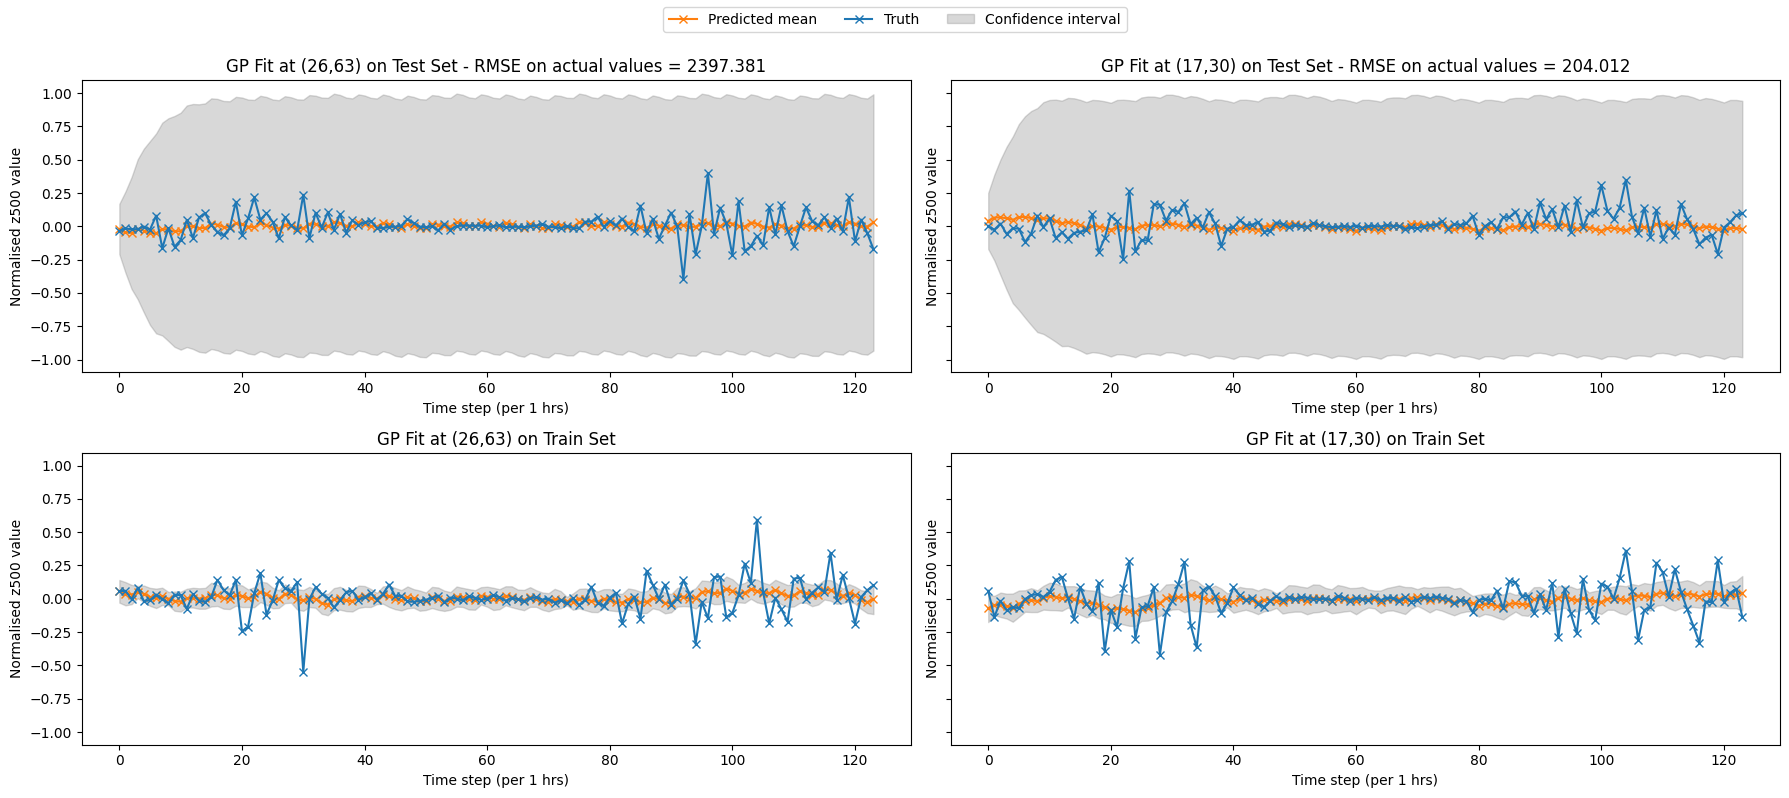

In [27]:
# Create a 2x3 figure
fig, axes = plt.subplots(2, 2, figsize=(18, 8), sharex=False, sharey=True)

idx = [rmse_max_idx, rmse_min_idx]
val = [rmse_max_err, rmse_min_err]

for i, p_idx in enumerate(idx):
    flat_idx = np.unravel_index(p_idx, rmse_error_mean.shape)
    ax = axes[0, i]  

    pred_vals = Y_pred.reshape(-1)[p_idx::(nlat*nlon)]
    truth_vals = Y_test.reshape(-1)[p_idx::(nlat*nlon)]
    std_vals = Y_std.reshape(-1)[p_idx::(nlat*nlon)]

    ax.plot(pred_vals, marker='x', label='Predicted mean', color='tab:orange')
    ax.plot(truth_vals, marker='x', label='Truth', color='tab:blue')
    ax.fill_between(np.arange(len(pred_vals)),
                    pred_vals - 2 * std_vals,
                    pred_vals + 2 * std_vals,
                    alpha=0.3, color='tab:gray', label='Confidence interval')
    ax.set_xlabel(f"Time step (per {time_subsample} hrs)")
    ax.set_ylabel("Normalised z500 value")
    ax.set_title(f"GP Fit at ({int(flat_idx[0])},{int(flat_idx[1])}) on Test Set - RMSE on actual values = {val[i]:.3f}")

for i, p_idx in enumerate(idx):
    flat_idx = np.unravel_index(p_idx, rmse_error_mean.shape)
    ax = axes[1, i]  

    pred_vals = train_mean.reshape(-1)[p_idx::(nlat*nlon)]
    truth_vals = Y_train.reshape(-1)[p_idx::(nlat*nlon)]
    std_vals = train_std.reshape(-1)[p_idx::(nlat*nlon)]

    ax.plot(pred_vals, marker='x', label='Predicted mean', color='tab:orange')
    ax.plot(truth_vals, marker='x', label='Truth', color='tab:blue')
    ax.fill_between(np.arange(len(pred_vals)),
                    pred_vals - 2 * std_vals,
                    pred_vals + 2 * std_vals,
                    alpha=0.3, color='tab:gray', label='Confidence interval')
    ax.set_xlabel(f"Time step (per {time_subsample} hrs)")
    ax.set_ylabel("Normalised z500 value")
    ax.set_title(f"GP Fit at ({int(flat_idx[0])},{int(flat_idx[1])}) on Train Set")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.savefig("STGP-weather-forecasting/tmp/posterior plot (rmse).png")
plt.show()

In [28]:
!mv STGP-weather-forecasting/tmp/* "STGP-weather-forecasting/plots/5.625deg/z500/Train (month), test (month)/vargp/3matern(0.04,0.08,0.5)+1matern2periodic(40,24,24*5)-rand(frac=0.05)-subsampletime6-train10epochs-detrend-after"

## Load saved model

In [29]:
"""lead_time = 24 # units of hours
space_subsample_ips = 5 # regular subsampling as inducing points
time_subsample_ips = 6 # regular subsampling as inducing points
space_subsample = 1
time_subsample = 1
batch_size = 2048

X_train, Y_train = create_data(data_train, data_test, lead_time, space_subsample, time_subsample)

# Inducing points technique
inducing_points = X_train[::time_subsample_ips, ::space_subsample_ips, ::space_subsample_ips,:].reshape(-1, 4)
X_train = X_train.view(-1,4) # Shape: (ntime*nlat*nlon, 4)
print(f"Number of inducing points / Total number of points: {inducing_points.size(0)/X_train.size(0)}")

train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

model = GPModel(inducing_points).to(device)
likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)

model.load_state_dict(torch.load("STGP-weather-forecasting/saved_models/vargp_model.pth"))
likelihood.load_state_dict(torch.load("STGP-weather-forecasting/saved_models/vargp_likelihood.pth"))"""

'lead_time = 24 # units of hours\nspace_subsample_ips = 5 # regular subsampling as inducing points\ntime_subsample_ips = 6 # regular subsampling as inducing points\nspace_subsample = 1\ntime_subsample = 1\nbatch_size = 2048\n\nX_train, Y_train = create_data(data_train, data_test, lead_time, space_subsample, time_subsample)\n\n# Inducing points technique\ninducing_points = X_train[::time_subsample_ips, ::space_subsample_ips, ::space_subsample_ips,:].reshape(-1, 4)\nX_train = X_train.view(-1,4) # Shape: (ntime*nlat*nlon, 4)\nprint(f"Number of inducing points / Total number of points: {inducing_points.size(0)/X_train.size(0)}")\n\ntrain_dataset = TensorDataset(X_train, Y_train)\ntrain_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)\n\nmodel = GPModel(inducing_points).to(device)\nlikelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)\n\nmodel.load_state_dict(torch.load("STGP-weather-forecasting/saved_models/vargp_model.pth"))\nlikelihood.load_state_dict(